In [18]:
import torch
import torch.nn as nn # Sinir ağı modülleri için
import matplotlib.pyplot as plt
import numpy as np
import random

# Önceki notebook'taki ayarlarımızı tekrar yapalım
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# --- Tensör Oluşturma ---
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print("Basit bir tensör:\n", x)

# --- Otomatik Türev (Autograd) ---
# requires_grad=True parametresi, PyTorch'a bu tensör üzerindeki
# her işlemi takip etmesini ve gradyanları hesaplamaya hazır olmasını söyler.
# Bu, sinir ağlarının öğrenmesinin temelidir.
x.requires_grad_(True)
y = x + 2
z = y * y * 3
out = z.mean()

# Geriye doğru yayılımı (backpropagation) başlatalım
out.backward() # Bu, gradyanları hesaplar

# Gradyanı (türevi) inceleyelim: d(out)/dx
# Bu, çıktıdaki (out) küçük bir değişimin girdideki (x) her bir elemanı
# ne kadar etkilediğini gösterir.
print("\nx'in gradyanı (dout/dx):\n", x.grad)

Using device: mps
Basit bir tensör:
 tensor([[1., 2.],
        [3., 4.]])

x'in gradyanı (dout/dx):
 tensor([[4.5000, 6.0000],
        [7.5000, 9.0000]])


Temel Bir Regresyon Problem Çözümü

In [19]:
# --- Basit Bir Model Tanımlayalım ---
# Bu model, tek bir girdiden (x) tek bir çıktı (y) üretmeye çalışacak.
# İçinde tek bir lineer katman barındıran çok basit bir ağ.

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # Modelimiz sadece bir tane öğrenilebilir katmandan oluşuyor:
        # 1 girdi özelliği (input feature) alıp, 1 çıktı özelliği (output feature) üreten
        # bir lineer katman.
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        # "forward" metodu, verinin model içinden nasıl akacağını tanımlar.
        # Girdi 'x', lineer katmandan geçer ve sonuç döndürülür.
        return self.linear(x)

# Modelimizi oluşturalım ve hangi cihazda çalışacağını belirtelim
model = LinearRegressionModel().to(device)
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [20]:
# --- Veri Seti Oluşturalım ---
# y = 2x + 1 ilişkisine sahip veri noktaları yaratalım.
# Üzerine biraz "gürültü" (noise) ekleyelim ki problem daha gerçekçi olsun.
X = torch.randn(100, 1) * 10  # -10 ile 10 arasında 100 rastgele x değeri
y_true = 2 * X + 1
y = y_true + torch.randn(100, 1) * 2 # Gürültü eklenmiş y değerleri

# Veriyi ve modeli cihaza taşıyalım
X, y = X.to(device), y.to(device)

# --- Eğitim Parametrelerini Tanımlayalım ---
learning_rate = 0.01
epochs = 100 # Veri setinin üzerinden kaç kere geçeceğimiz

# Kayıp Fonksiyonu (Loss Function): Modelin ne kadar "yanlış" olduğunu ölçer.
# Regresyon için genellikle Ortalama Kare Hata (Mean Squared Error) kullanılır.
loss_function = nn.MSELoss()

# Optimize Edici (Optimizer): Gradyanları kullanarak modelin ağırlıklarını günceller.
# En yaygın olanlardan biri Adam'dır.
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


# --- Eğitim Döngüsü ---
for epoch in range(epochs):
    # 1. İleri Yayılım (Forward Pass): Tahmin yap
    y_pred = model(X)

    # 2. Kaybı Hesapla (Calculate Loss): Tahmin ile gerçek değer arasındaki hatayı ölç
    loss = loss_function(y_pred, y)

    # 3. Gradyanları Sıfırla: Önceki adımdan kalan gradyanları temizle
    optimizer.zero_grad()

    # 4. Geriye Yayılım (Backward Pass): Kayba göre gradyanları hesapla
    loss.backward()

    # 5. Ağırlıkları Güncelle: Optimize ediciyi kullanarak parametreleri güncelle
    optimizer.step()

    # Her 10 epoch'ta bir ilerlemeyi yazdıralım
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 4.3558
Epoch [20/100], Loss: 2.9125
Epoch [30/100], Loss: 2.8993
Epoch [40/100], Loss: 2.8966
Epoch [50/100], Loss: 2.8948
Epoch [60/100], Loss: 2.8937
Epoch [70/100], Loss: 2.8929
Epoch [80/100], Loss: 2.8923
Epoch [90/100], Loss: 2.8920
Epoch [100/100], Loss: 2.8918


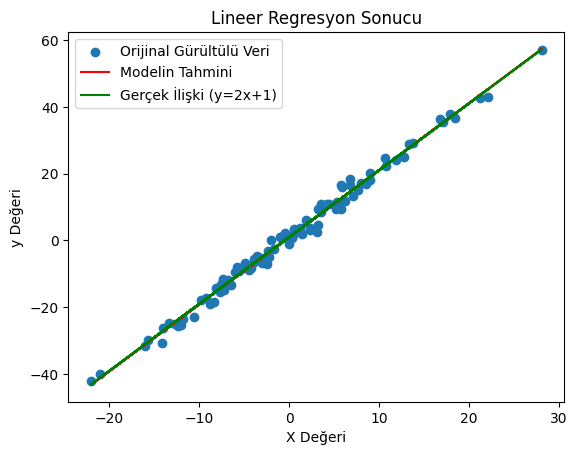


Öğrenilen Ağırlık (W): 2.0052 (Gerçek değer: 2)
Öğrenilen Bias (b): 0.9682 (Gerçek değer: 1)


In [21]:
# --- Sonuçları Görselleştirelim ---

# Modeli değerlendirme moduna alalım. Bu, eğitim sırasında kullanılan
# Dropout gibi katmanları devre dışı bırakır (bizim modelimizde yok ama iyi bir alışkanlıktır).
model.eval()

# Eğitilmiş model ile tahminler yapalım.
with torch.no_grad(): # Bu blok içinde gradyan hesaplaması yapılmayacağını belirtiriz.
    predicted = model(X).cpu() # Tahminleri CPU'ya geri taşıyalım

# Grafiği çizelim
# Önce veri noktalarını (gürültülü olanları) saçılım grafiği olarak çizelim
plt.scatter(X.cpu(), y.cpu(), label='Orijinal Gürültülü Veri')

# Sonra modelimizin öğrendiği doğruyu (kırmızı çizgi) çizelim
plt.plot(X.cpu(), predicted, color='red', label='Modelin Tahmini')

# İdealde olması gereken doğruyu da (yeşil çizgi) ekleyelim
plt.plot(X.cpu(), y_true.cpu(), color='green', label='Gerçek İlişki (y=2x+1)')

plt.title('Lineer Regresyon Sonucu')
plt.xlabel('X Değeri')
plt.ylabel('y Değeri')
plt.legend()
plt.show()

# Modelin öğrendiği parametrelere de bakalım
[w, b] = model.parameters()
print(f"\nÖğrenilen Ağırlık (W): {w[0][0].item():.4f} (Gerçek değer: 2)")
print(f"Öğrenilen Bias (b): {b[0].item():.4f} (Gerçek değer: 1)")